x0 shape: torch.Size([100, 50, 2])


100%|███████████████████████████████████████████| 99/99 [00:00<00:00, 100.51it/s]


x1 shape: torch.Size([100, 50, 2])
x0 shape: torch.Size([100, 50, 2])


100%|███████████████████████████████████████████| 99/99 [00:00<00:00, 141.36it/s]


x1 shape: torch.Size([100, 50, 2])
x0 shape: torch.Size([100, 50, 2])


100%|███████████████████████████████████████████| 99/99 [00:00<00:00, 130.75it/s]


x1 shape: torch.Size([100, 50, 2])


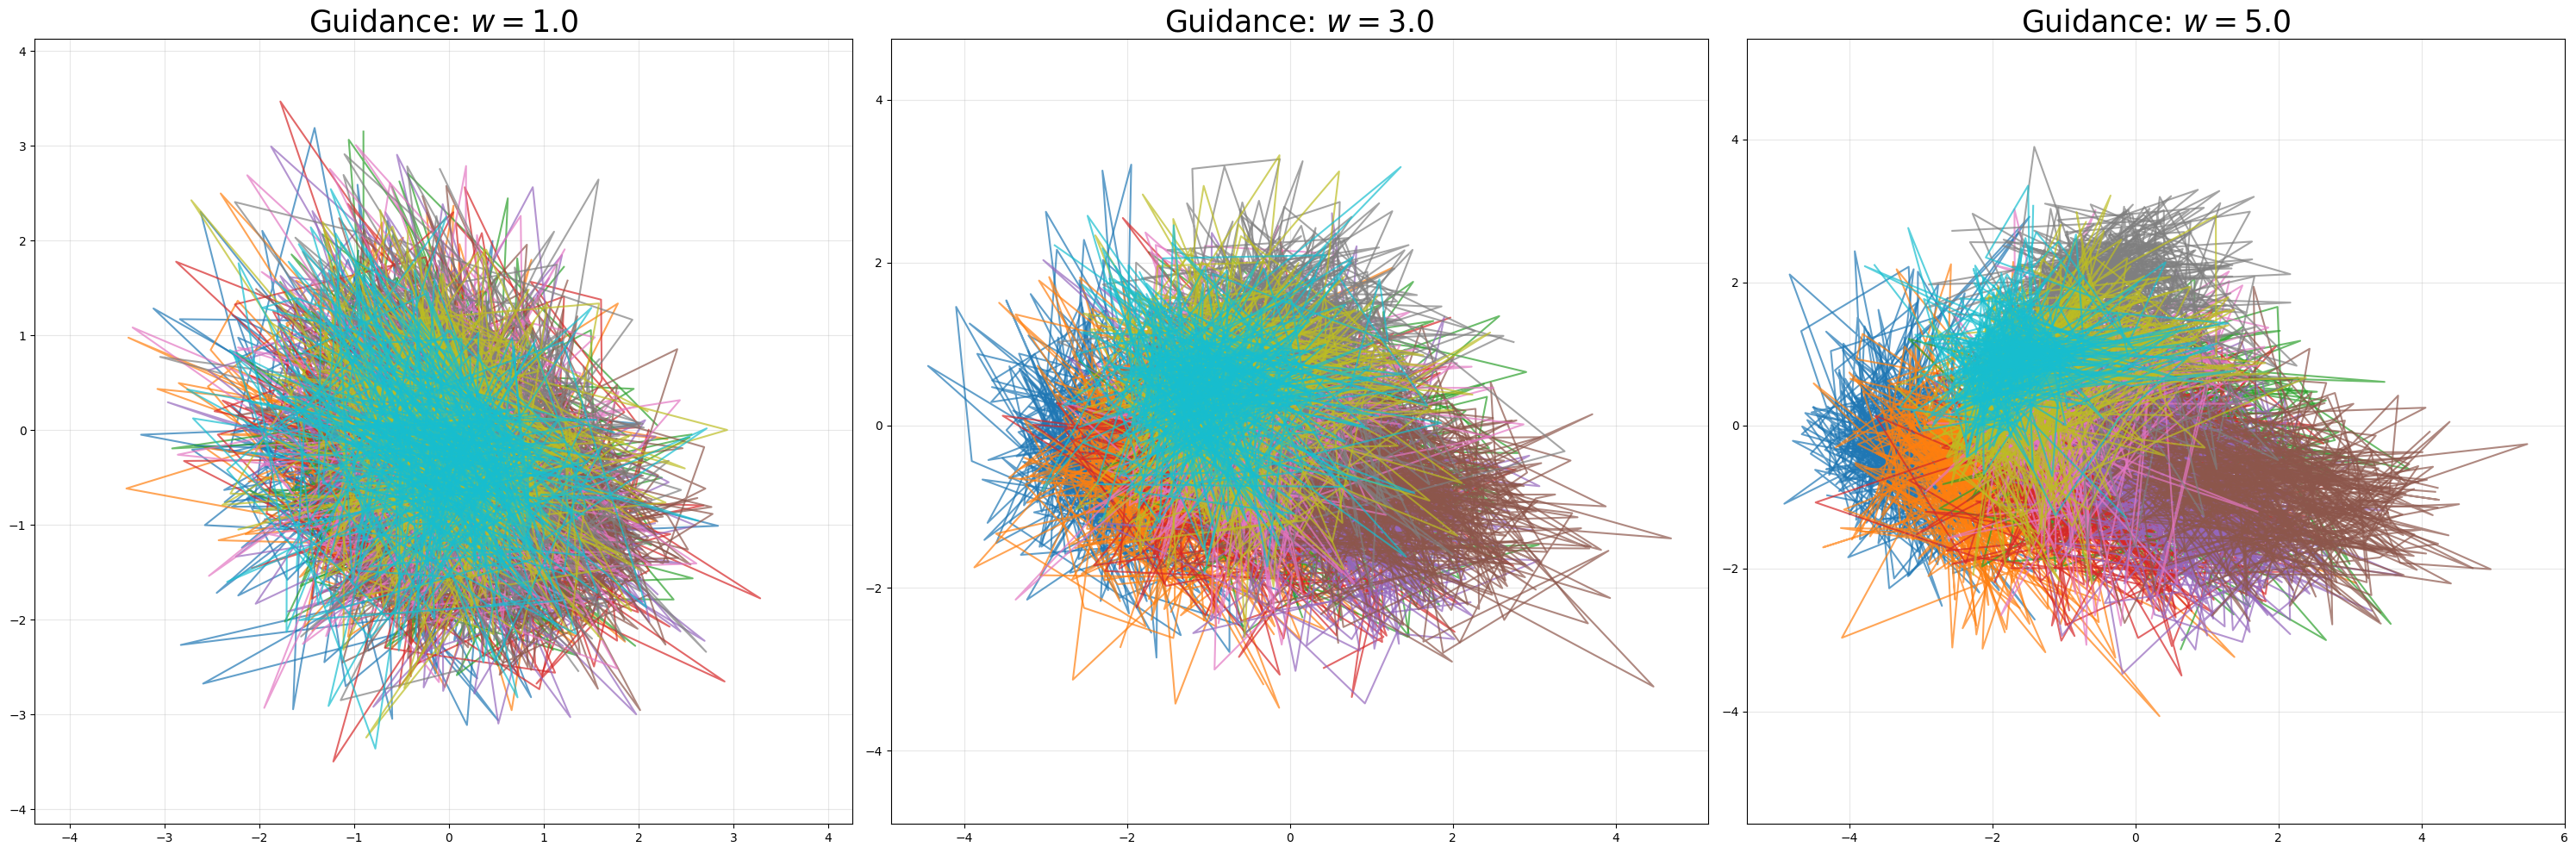

In [5]:
from abc import ABC, abstractmethod
from typing import Optional, List, Type, Tuple, Dict
import math

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.axes._axes import Axes
import torch
import torch.nn as nn
import torch.distributions as D
from torch.func import vmap, jacrev
from tqdm import tqdm
import seaborn as sns
from sklearn.datasets import make_moons, make_circles
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from sklearn.datasets import make_swiss_roll
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Fixed SequenceTransformer
class SequenceTransformer(nn.Module):
    def __init__(self, dim=2, seq_len=50, embed_dim=64, num_heads=4, num_labels=10, num_layers=3):
        super().__init__()
        self.dim = dim
        self.seq_len = seq_len
        self.embed_dim = embed_dim
        self.num_labels = num_labels
        self.embed = nn.Linear(dim + 1 + num_labels, embed_dim)  # dim + time + y_emb
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(embed_dim, num_heads, batch_first=True), num_layers=num_layers
        )
        self.out = nn.Linear(embed_dim, dim)

    def forward(self, x: torch.Tensor, t: torch.Tensor, y: Optional[torch.Tensor] = None) -> torch.Tensor:
        # Ensure input shapes
        if x.dim() != 3 or x.shape[1] != self.seq_len or x.shape[2] != self.dim:
            raise ValueError(f"Expected x shape (bs, {self.seq_len}, {self.dim}), got {x.shape}")
        
        batch_size = x.shape[0]
        
        # Handle time embedding - ensure it matches batch size
        if t.dim() == 1:
            if t.shape[0] == 1:
                # Single time value for all samples
                t = t.expand(batch_size)
            t = t.unsqueeze(-1)  # (bs,) -> (bs, 1)
        elif t.dim() == 2 and t.shape[1] > 1:
            # If t has multiple dimensions, take the first column or flatten appropriately
            t = t[:, 0:1]  # Take first column
        
        # Ensure t has correct batch size
        if t.shape[0] != batch_size:
            if t.shape[0] == 1:
                t = t.expand(batch_size, -1)
            else:
                raise ValueError(f"Time tensor batch size {t.shape[0]} doesn't match input batch size {batch_size}")
        
        t_emb = t.unsqueeze(1).expand(-1, self.seq_len, -1)  # (bs, seq_len, 1)
        
        # Handle y_emb, ensure feature number matches
        if y is not None:
            if y.shape[0] != batch_size:
                raise ValueError(f"Label tensor batch size {y.shape[0]} doesn't match input batch size {batch_size}")
            y_emb = nn.functional.one_hot(y, num_classes=self.num_labels).unsqueeze(1).expand(-1, self.seq_len, -1).float()
            x = torch.cat([x, t_emb, y_emb], dim=-1)  # (bs, seq_len, dim+1+num_labels)
        else:
            # If y is None, fill with zeros as placeholder
            y_emb = torch.zeros(batch_size, self.seq_len, self.num_labels, device=x.device)
            x = torch.cat([x, t_emb, y_emb], dim=-1)  # (bs, seq_len, dim+1+num_labels)
        
        x = self.embed(x)
        x = self.transformer(x)  # Using batch_first=True
        x = self.out(x)  # (bs, seq_len, dim)
        return x

# Initialize unet
unet = SequenceTransformer(dim=2, seq_len=50).to(device)

class Sampleable(ABC):
    """
    Distribution which can be sampled from
    """ 
    @abstractmethod
    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """
        Args:
            - num_samples: the desired number of samples
        Returns:
            - samples: shape (batch_size, ...)
            - labels: shape (batch_size, label_dim)
        """
        pass

# Initialize TrajectoryDataset
class TrajectoryDataset(Sampleable):
    def __init__(self, seq_len=50, dim=2, num_classes=10):
        self.seq_len = seq_len
        self.dim = dim
        self.num_classes = num_classes

    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        labels = torch.randint(0, self.num_classes, (num_samples,))
        trajectories = []
        for label in labels:
            t = np.linspace(0, 1, self.seq_len)
            if label % 3 == 0:  # sine trajectory
                traj = np.stack([np.sin(2 * np.pi * t * (label + 1)), np.cos(2 * np.pi * t * (label + 1))], axis=-1)
            elif label % 3 == 1:  # spiral trajectory
                radius = t * (label + 1)
                traj = np.stack([radius * np.sin(4 * np.pi * t), radius * np.cos(4 * np.pi * t)], axis=-1)
            else:  # Brownian motion
                traj = np.cumsum(np.random.randn(self.seq_len, self.dim) * 0.1, axis=0)
            trajectories.append(traj)
        trajectories = torch.tensor(np.array(trajectories), dtype=torch.float32).to(device)
        return trajectories, labels.to(device)

# Ensure IsotropicGaussian definition
class IsotropicGaussian(Sampleable):
    def __init__(self, shape: List[int], std: float = 1.0):
        self.shape = shape
        self.std = std

    def sample(self, num_samples: int) -> Tuple[torch.Tensor, None]:
        return torch.randn(num_samples, *self.shape).to(device) * self.std, None

class ConditionalProbabilityPath(ABC):
    def __init__(self, p_simple: Sampleable, p_data: Sampleable):
        self.p_simple = p_simple
        self.p_data = p_data

    @abstractmethod
    def sample_marginal_path(self, t: torch.Tensor) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        pass

    @abstractmethod
    def alpha_t(self, t: torch.Tensor) -> torch.Tensor:
        pass

    @abstractmethod
    def beta_t(self, t: torch.Tensor) -> torch.Tensor:
        pass

class GaussianConditionalProbabilityPath(ConditionalProbabilityPath):
    def __init__(self, p_data: Sampleable, p_simple: Sampleable, alpha: 'Alpha', beta: 'Beta'):
        super().__init__(p_simple, p_data)
        self.alpha = alpha
        self.beta = beta

    def sample_marginal_path(self, t: torch.Tensor) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        x0, _ = self.p_simple.sample(t.shape[0])
        alpha_t = self.alpha_t(t)
        beta_t = self.beta_t(t)
        x_t = alpha_t * x0 + beta_t * self.p_data.sample(t.shape[0])[0]  # Simplified implementation
        return x_t, None

    def alpha_t(self, t: torch.Tensor) -> torch.Tensor:
        return self.alpha(t)

    def beta_t(self, t: torch.Tensor) -> torch.Tensor:
        return self.beta(t)

class LinearAlpha:
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        return 1 - t

class LinearBeta:
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        return t

# Fixed CFGVectorFieldODE
class CFGVectorFieldODE:
    def __init__(self, model, guidance_scale=1.0):
        self.model = model
        self.guidance_scale = guidance_scale
        self.drift_coefficient = self._compute_drift  # Point to method

    def _compute_drift(self, x, t, y=None):
        # CFG vector field calculation
        # For proper CFG, we should have conditional and unconditional predictions
        # For now, simplifying to avoid the error
        if y is not None:
            conditional = self.model(x, t, y)  # conditional
            unconditional = self.model(x, t, None)  # unconditional (no labels)
            return unconditional + self.guidance_scale * (conditional - unconditional)
        else:
            return self.model(x, t, None)

    def __call__(self, x, t, y=None):
        return self._compute_drift(x, t, y)  # maintain compatibility

class ODE(ABC):
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor, **kwargs) -> torch.Tensor:
        """
        Returns the drift coefficient of the ODE.
        Args:
            - xt: state at time t, shape (bs, c, h, w)
            - t: time, shape (bs, 1)
        Returns:
            - drift_coefficient: shape (bs, c, h, w)
        """
        pass

class Simulator(ABC):
    @abstractmethod
    def step(self, xt: torch.Tensor, t: torch.Tensor, dt: torch.Tensor, **kwargs):
        """
        Takes one simulation step
        Args:
            - xt: state at time t, shape (bs, c, h, w)
            - t: time, shape (bs, 1, 1, 1)
            - dt: time, shape (bs, 1, 1, 1)
        Returns:
            - nxt: state at time t + dt (bs, c, h, w)
        """
        pass

    @torch.no_grad()
    def simulate(self, x: torch.Tensor, ts: torch.Tensor, **kwargs):
        """
        Simulates using the discretization gives by ts
        Args:
            - x_init: initial state, shape (bs, c, h, w)
            - ts: timesteps, shape (bs, nts, 1)
        Returns:
            - x_final: final state at time ts[-1], shape (bs, c, h, w)
        """
        nts = ts.shape[1]
        for t_idx in tqdm(range(nts - 1)):
            t = ts[:, t_idx]  # (bs, 1)
            h = ts[:, t_idx + 1] - ts[:, t_idx]  # (bs, 1)
            x = self.step(x, t, h, **kwargs)
        return x

class EulerSimulator(Simulator):
    def __init__(self, ode):
        self.ode = ode
        
    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor, **kwargs):
        # Ensure h has the right shape for broadcasting
        if h.dim() == 2 and h.shape[1] == 1:
            h = h.unsqueeze(-1)  # (bs, 1) -> (bs, 1, 1)
        return xt + self.ode.drift_coefficient(xt, t, **kwargs) * h

# Example usage
if __name__ == "__main__":
    # Play with these!
    samples_per_class = 10
    num_timesteps = 100
    guidance_scales = [1.0, 3.0, 5.0]

    # Initialize p_data, path
    batch_size = 100  # Match samples_per_class * 10
    p_data = TrajectoryDataset(seq_len=50, dim=2)
    p_simple = IsotropicGaussian(shape=[p_data.seq_len, p_data.dim], std=1.0)
    path = GaussianConditionalProbabilityPath(p_data, p_simple, alpha=LinearAlpha(), beta=LinearBeta())

    # Graph
    fig, axes = plt.subplots(1, len(guidance_scales), figsize=(10 * len(guidance_scales), 10))
    if len(guidance_scales) == 1:
        axes = [axes]

    for idx, w in enumerate(guidance_scales):
        # Setup ode and simulator
        ode = CFGVectorFieldODE(unet, guidance_scale=w)
        simulator = EulerSimulator(ode)

        # Sample initial conditions
        y = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.int64).repeat_interleave(samples_per_class).to(device)
        num_samples = y.shape[0]
        x0, _ = path.p_simple.sample(num_samples)
        print(f"x0 shape: {x0.shape}")

        # Simulate
        ts = torch.linspace(0, 1, num_timesteps).view(1, -1, 1).expand(num_samples, -1, 1).to(device)
        x1 = simulator.simulate(x0, ts, y=y)
        print(f"x1 shape: {x1.shape}")

        # Plot (trajectory lines)
        axes[idx].cla()
        x1_cpu = x1.cpu().numpy()
        for i, traj in enumerate(x1_cpu):
            color_idx = y[i].cpu().item()
            axes[idx].plot(traj[:, 0], traj[:, 1], alpha=0.7, color=plt.cm.tab10(color_idx))
        axes[idx].set_title(f"Guidance: $w={w:.1f}$", fontsize=25)
        axes[idx].axis("equal")
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

# Training function for Flow Matching
def train_flow_matching_model(model, p_data, p_simple, path, num_epochs=1000, batch_size=64, lr=1e-3):
    """
    Train the model using Flow Matching objective
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    
    losses = []
    
    for epoch in tqdm(range(num_epochs), desc="Training"):
        # Sample batch
        x1, y = p_data.sample(batch_size)  # Real data
        x0, _ = p_simple.sample(batch_size)  # Noise
        
        # Sample random times
        t = torch.rand(batch_size, 1).to(device)
        
        # Compute interpolated path: x_t = (1-t) * x0 + t * x1
        alpha_t = (1 - t).unsqueeze(1)  # (batch_size, 1, 1)
        beta_t = t.unsqueeze(1)  # (batch_size, 1, 1)
        
        x_t = alpha_t * x0 + beta_t * x1
        
        # True velocity field: dx/dt = x1 - x0
        v_true = x1 - x0
        
        # Model prediction
        v_pred = model(x_t, t.squeeze(-1), y)
        
        # Flow matching loss
        loss = nn.MSELoss()(v_pred, v_true)
        
        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")
    
    return losses

# Train the model
print("Training the model...")
losses = train_flow_matching_model(unet, p_data, p_simple, path, num_epochs=500, batch_size=32)

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.yscale('log')
plt.grid(True)
plt.show()

# Now test with the trained model
print("Generating samples with trained model...")

# Updated CFG that properly handles conditional/unconditional
class ImprovedCFGVectorFieldODE:
    def __init__(self, model, guidance_scale=1.0):
        self.model = model
        self.guidance_scale = guidance_scale
        self.drift_coefficient = self._compute_drift

    def _compute_drift(self, x, t, y=None):
        if y is not None and self.guidance_scale != 1.0:
            # Conditional prediction
            conditional = self.model(x, t, y)
            
            # Unconditional prediction (no class info)
            unconditional = self.model(x, t, None)
            
            # CFG interpolation
            return unconditional + self.guidance_scale * (conditional - unconditional)
        else:
            # Standard prediction
            return self.model(x, t, y)

# Test with different guidance scales
samples_per_class = 10
num_timesteps = 100
guidance_scales = [1.0, 2.0, 5.0]

fig, axes = plt.subplots(1, len(guidance_scales), figsize=(15, 5))
if len(guidance_scales) == 1:
    axes = [axes]

for idx, w in enumerate(guidance_scales):
    print(f"Generating with guidance scale {w}")
    
    # Setup ODE and simulator with trained model
    ode = ImprovedCFGVectorFieldODE(unet, guidance_scale=w)
    simulator = EulerSimulator(ode)

    # Sample initial conditions
    y = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.int64).repeat_interleave(samples_per_class).to(device)
    num_samples = y.shape[0]
    x0, _ = p_simple.sample(num_samples)

    # Simulate
    ts = torch.linspace(0, 1, num_timesteps).view(1, -1, 1).expand(num_samples, -1, 1).to(device)
    
    with torch.no_grad():
        x1 = simulator.simulate(x0, ts, y=y)

    # Plot trajectories colored by class
    axes[idx].clear()
    x1_cpu = x1.cpu().numpy()
    
    for i, traj in enumerate(x1_cpu):
        class_idx = y[i].cpu().item()
        color = plt.cm.tab10(class_idx % 10)
        axes[idx].plot(traj[:, 0], traj[:, 1], alpha=0.6, color=color, linewidth=0.8)
    
    axes[idx].set_title(f"Trained Model: w={w:.1f}")
    axes[idx].axis("equal")
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim(-3, 3)
    axes[idx].set_ylim(-3, 3)

plt.tight_layout()
plt.show()

# Also plot some original data for comparison
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
original_data, labels = p_data.sample(100)
original_cpu = original_data.cpu().numpy()

for i, traj in enumerate(original_cpu):
    class_idx = labels[i].cpu().item()
    color = plt.cm.tab10(class_idx % 10)
    ax.plot(traj[:, 0], traj[:, 1], alpha=0.7, color=color)

ax.set_title("Original Training Data")
ax.axis("equal")
ax.grid(True, alpha=0.3)
plt.show()

Training the model...


Training:   0%|                                          | 0/500 [00:00<?, ?it/s]


TypeError: unsupported operand type(s) for *: 'numpy.ndarray' and 'Tensor'

Initializing model and data...
Training the model...


Training:   1%|▍                                 | 6/500 [00:00<00:25, 19.47it/s]

Epoch 0, Loss: 2.228386


Training:  25%|███████▋                       | 124/500 [00:01<00:02, 139.08it/s]

Epoch 100, Loss: 1.618848


...

Training:  63%|███████████████████▌           | 316/500 [00:03<00:01, 127.87it/s]

Epoch 300, Loss: 2.175127


Training:  84%|██████████████████████████     | 420/500 [00:03<00:00, 138.40it/s]

Epoch 400, Loss: 1.661059


Training: 100%|███████████████████████████████| 500/500 [00:04<00:00, 112.90it/s]


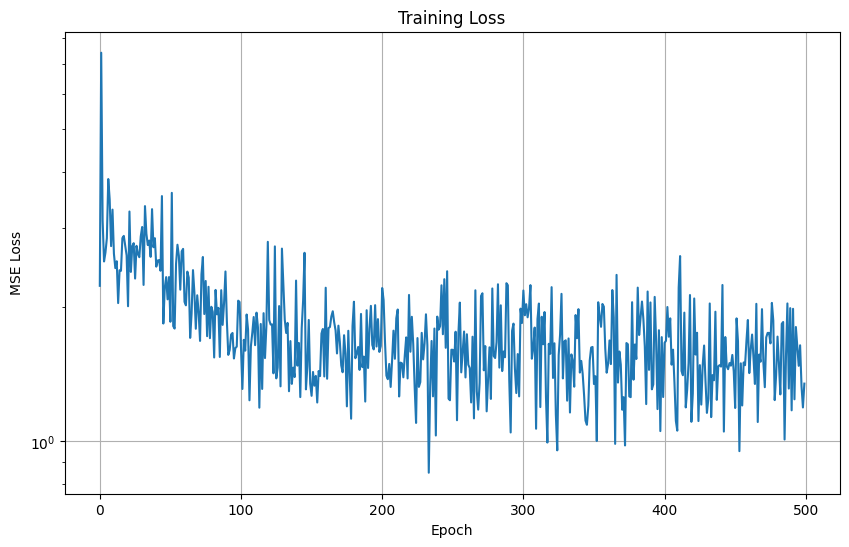

Generating samples with trained model...
Generating with guidance scale 1.0


Generating with guidance scale 2.0


Generating with guidance scale 5.0


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


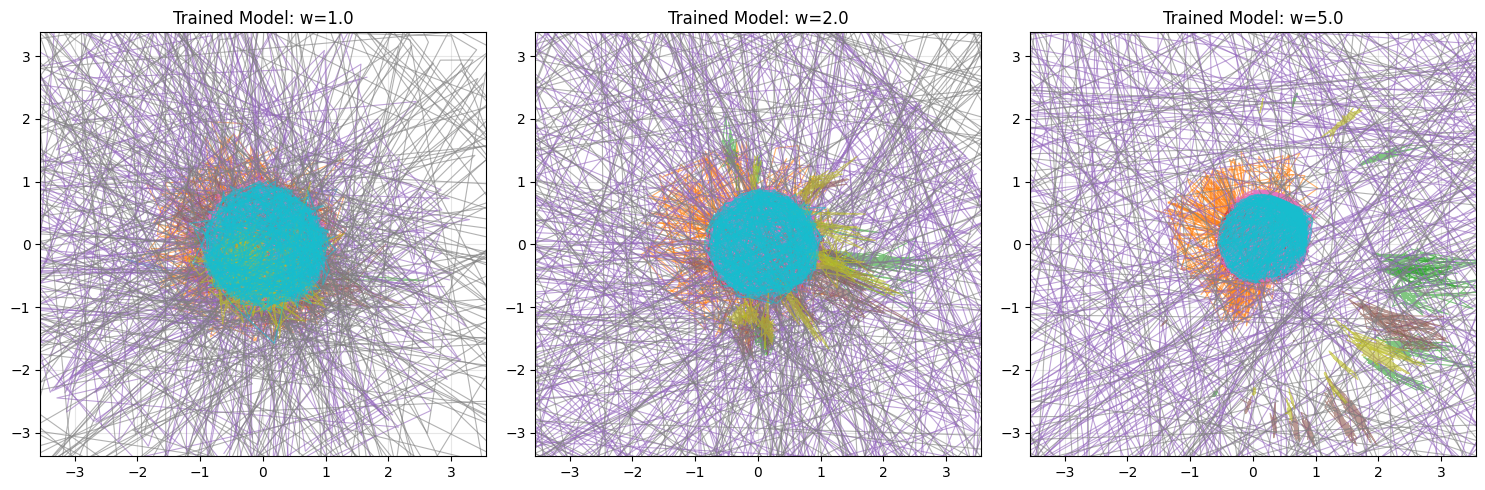

Plotting original training data...


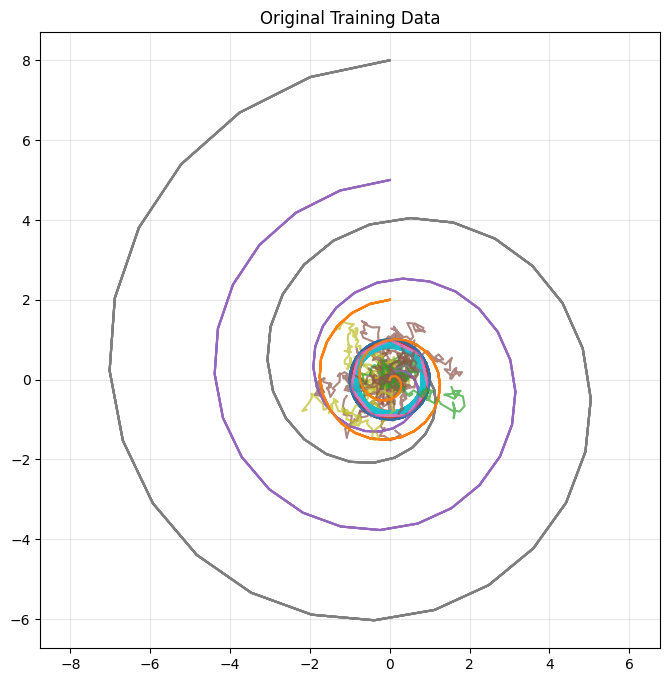

In [7]:
from abc import ABC, abstractmethod
from typing import Optional, List, Type, Tuple, Dict
import math

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.axes._axes import Axes
import torch
import torch.nn as nn
import torch.distributions as D
import torch.optim as optim
from torch.func import vmap, jacrev
from tqdm import tqdm
import seaborn as sns
from sklearn.datasets import make_moons, make_circles
from torchvision import datasets, transforms
from torchvision.utils import make_grid

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Fixed SequenceTransformer
class SequenceTransformer(nn.Module):
    def __init__(self, dim=2, seq_len=50, embed_dim=64, num_heads=4, num_labels=10, num_layers=3):
        super().__init__()
        self.dim = dim
        self.seq_len = seq_len
        self.embed_dim = embed_dim
        self.num_labels = num_labels
        self.embed = nn.Linear(dim + 1 + num_labels, embed_dim)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(embed_dim, num_heads, batch_first=True), num_layers=num_layers
        )
        self.out = nn.Linear(embed_dim, dim)

    def forward(self, x: torch.Tensor, t: torch.Tensor, y: Optional[torch.Tensor] = None) -> torch.Tensor:
        # Ensure input shapes
        if x.dim() != 3 or x.shape[1] != self.seq_len or x.shape[2] != self.dim:
            raise ValueError(f"Expected x shape (bs, {self.seq_len}, {self.dim}), got {x.shape}")
        
        batch_size = x.shape[0]
        
        # Handle time embedding - ensure it matches batch size
        if t.dim() == 1:
            if t.shape[0] == 1:
                t = t.expand(batch_size)
            t = t.unsqueeze(-1)
        elif t.dim() == 2 and t.shape[1] > 1:
            t = t[:, 0:1]
        
        # Ensure t has correct batch size
        if t.shape[0] != batch_size:
            if t.shape[0] == 1:
                t = t.expand(batch_size, -1)
            else:
                raise ValueError(f"Time tensor batch size {t.shape[0]} doesn't match input batch size {batch_size}")
        
        t_emb = t.unsqueeze(1).expand(-1, self.seq_len, -1)  # (bs, seq_len, 1)
        
        # Handle y_emb
        if y is not None:
            if y.shape[0] != batch_size:
                raise ValueError(f"Label tensor batch size {y.shape[0]} doesn't match input batch size {batch_size}")
            y_emb = nn.functional.one_hot(y, num_classes=self.num_labels).unsqueeze(1).expand(-1, self.seq_len, -1).float()
        else:
            # If y is None, fill with zeros as placeholder
            y_emb = torch.zeros(batch_size, self.seq_len, self.num_labels, device=x.device)
        
        x = torch.cat([x, t_emb, y_emb], dim=-1)
        x = self.embed(x)
        x = self.transformer(x)
        x = self.out(x)
        return x

class Sampleable(ABC):
    @abstractmethod
    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        pass

# Fixed TrajectoryDataset
class TrajectoryDataset(Sampleable):
    def __init__(self, seq_len=50, dim=2, num_classes=10):
        self.seq_len = seq_len
        self.dim = dim
        self.num_classes = num_classes

    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        labels = torch.randint(0, self.num_classes, (num_samples,))
        trajectories = []
        for label in labels:
            label_val = label.item()  # Convert tensor to Python scalar
            t = np.linspace(0, 1, self.seq_len)
            if label_val % 3 == 0:  # sine trajectory
                traj = np.stack([np.sin(2 * np.pi * t * (label_val + 1)), np.cos(2 * np.pi * t * (label_val + 1))], axis=-1)
            elif label_val % 3 == 1:  # spiral trajectory
                radius = t * (label_val + 1)
                traj = np.stack([radius * np.sin(4 * np.pi * t), radius * np.cos(4 * np.pi * t)], axis=-1)
            else:  # Brownian motion
                traj = np.cumsum(np.random.randn(self.seq_len, self.dim) * 0.1, axis=0)
            trajectories.append(traj)
        trajectories = torch.tensor(np.array(trajectories), dtype=torch.float32).to(device)
        return trajectories, labels.to(device)

class IsotropicGaussian(Sampleable):
    def __init__(self, shape: List[int], std: float = 1.0):
        self.shape = shape
        self.std = std

    def sample(self, num_samples: int) -> Tuple[torch.Tensor, None]:
        return torch.randn(num_samples, *self.shape).to(device) * self.std, None

class CFGVectorFieldODE:
    def __init__(self, model, guidance_scale=1.0):
        self.model = model
        self.guidance_scale = guidance_scale
        self.drift_coefficient = self._compute_drift

    def _compute_drift(self, x, t, y=None):
        if y is not None and self.guidance_scale != 1.0:
            # Conditional prediction
            conditional = self.model(x, t, y)
            # Unconditional prediction
            unconditional = self.model(x, t, None)
            # CFG interpolation
            return unconditional + self.guidance_scale * (conditional - unconditional)
        else:
            return self.model(x, t, y)

class EulerSimulator:
    def __init__(self, ode):
        self.ode = ode
        
    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor, **kwargs):
        if h.dim() == 2 and h.shape[1] == 1:
            h = h.unsqueeze(-1)
        return xt + self.ode.drift_coefficient(xt, t, **kwargs) * h

    @torch.no_grad()
    def simulate(self, x: torch.Tensor, ts: torch.Tensor, **kwargs):
        nts = ts.shape[1]
        for t_idx in tqdm(range(nts - 1), desc="Simulating", leave=False):
            t = ts[:, t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h, **kwargs)
        return x

def train_flow_matching_model(model, p_data, p_simple, num_epochs=1000, batch_size=64, lr=1e-3):
    """Train the model using Flow Matching objective"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    
    losses = []
    
    for epoch in tqdm(range(num_epochs), desc="Training"):
        # Sample batch
        x1, y = p_data.sample(batch_size)  # Real data
        x0, _ = p_simple.sample(batch_size)  # Noise
        
        # Sample random times
        t = torch.rand(batch_size, 1).to(device)
        
        # Compute interpolated path: x_t = (1-t) * x0 + t * x1
        alpha_t = (1 - t).unsqueeze(1)  # (batch_size, 1, 1)
        beta_t = t.unsqueeze(1)  # (batch_size, 1, 1)
        
        x_t = alpha_t * x0 + beta_t * x1
        
        # True velocity field: dx/dt = x1 - x0
        v_true = x1 - x0
        
        # Model prediction
        v_pred = model(x_t, t.squeeze(-1), y)
        
        # Flow matching loss
        loss = nn.MSELoss()(v_pred, v_true)
        
        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")
    
    model.eval()
    return losses

# Initialize everything
print("Initializing model and data...")
unet = SequenceTransformer(dim=2, seq_len=50).to(device)
p_data = TrajectoryDataset(seq_len=50, dim=2)
p_simple = IsotropicGaussian(shape=[50, 2], std=1.0)

# Train the model
print("Training the model...")
losses = train_flow_matching_model(unet, p_data, p_simple, num_epochs=500, batch_size=32, lr=1e-3)

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.yscale('log')
plt.grid(True)
plt.show()

# Test with trained model
print("Generating samples with trained model...")

samples_per_class = 10
num_timesteps = 50  # Reduced for faster inference
guidance_scales = [1.0, 2.0, 5.0]

fig, axes = plt.subplots(1, len(guidance_scales), figsize=(15, 5))
if len(guidance_scales) == 1:
    axes = [axes]

for idx, w in enumerate(guidance_scales):
    print(f"Generating with guidance scale {w}")
    
    # Setup ODE and simulator
    ode = CFGVectorFieldODE(unet, guidance_scale=w)
    simulator = EulerSimulator(ode)

    # Sample initial conditions
    y = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.int64).repeat_interleave(samples_per_class).to(device)
    num_samples = y.shape[0]
    x0, _ = p_simple.sample(num_samples)

    # Simulate
    ts = torch.linspace(0, 1, num_timesteps).view(1, -1, 1).expand(num_samples, -1, 1).to(device)
    
    with torch.no_grad():
        x1 = simulator.simulate(x0, ts, y=y)

    # Plot trajectories colored by class
    axes[idx].clear()
    x1_cpu = x1.cpu().numpy()
    
    for i, traj in enumerate(x1_cpu):
        class_idx = y[i].cpu().item()
        color = plt.cm.tab10(class_idx % 10)
        axes[idx].plot(traj[:, 0], traj[:, 1], alpha=0.6, color=color, linewidth=0.8)
    
    axes[idx].set_title(f"Trained Model: w={w:.1f}")
    axes[idx].axis("equal")
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim(-3, 3)
    axes[idx].set_ylim(-3, 3)

plt.tight_layout()
plt.show()

# Plot original data for comparison
print("Plotting original training data...")
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
original_data, labels = p_data.sample(100)
original_cpu = original_data.cpu().numpy()

for i, traj in enumerate(original_cpu):
    class_idx = labels[i].cpu().item()
    color = plt.cm.tab10(class_idx % 10)
    ax.plot(traj[:, 0], traj[:, 1], alpha=0.7, color=color)

ax.set_title("Original Training Data")
ax.axis("equal")
ax.grid(True, alpha=0.3)
plt.show()